## Data Loading and Initial Preprocessing

In this step, we import the required libraries and load the raw dataset.
We also clean the TotalCharges column by converting it to numeric format and imputing missing values with the median.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("husl")

df = pd.read_csv('../data/raw_data.csv')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Target Variable Distribution

We visualize the distribution of the target variable Churn to understand class balance.
The dataset is imbalanced, with 26.5% customers labeled as "Yes" (churn) and the majority belonging to the "No" class.

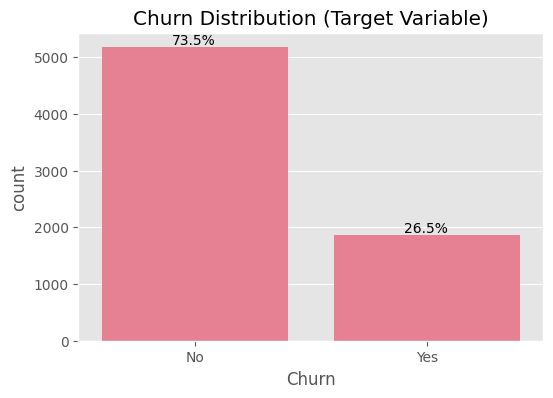

In [2]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution (Target Variable)')

total = len(df['Churn'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + 0.3, p.get_height() + 50))
plt.show()

## Churn by Contract Type

We examine churn behavior across different contract types.
Customers with Month-to-Month contracts show a significantly higher churn rate compared to those with One-Year or Two-Year contracts.

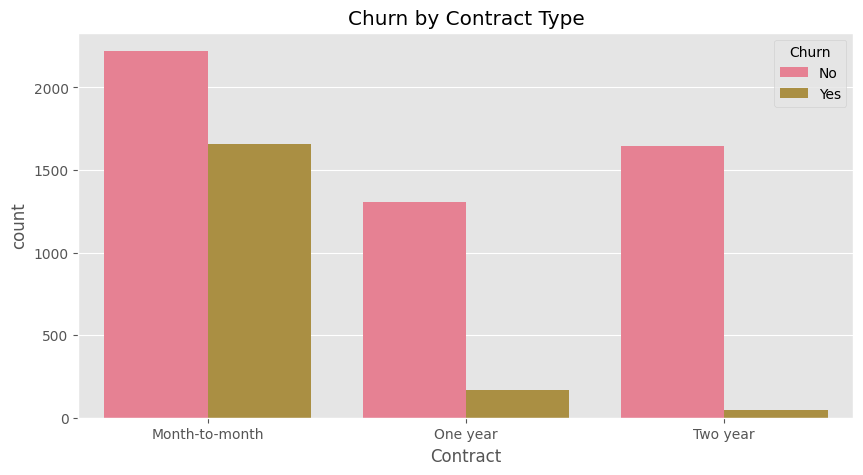

In [3]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

## Tenure Distribution by Churn Status

We compare the tenure distribution between retained and churned customers using density plots.
The results indicate that newer customers (shorter tenure) are at significantly higher risk of churn, while long-tenure customers tend to remain loyal.

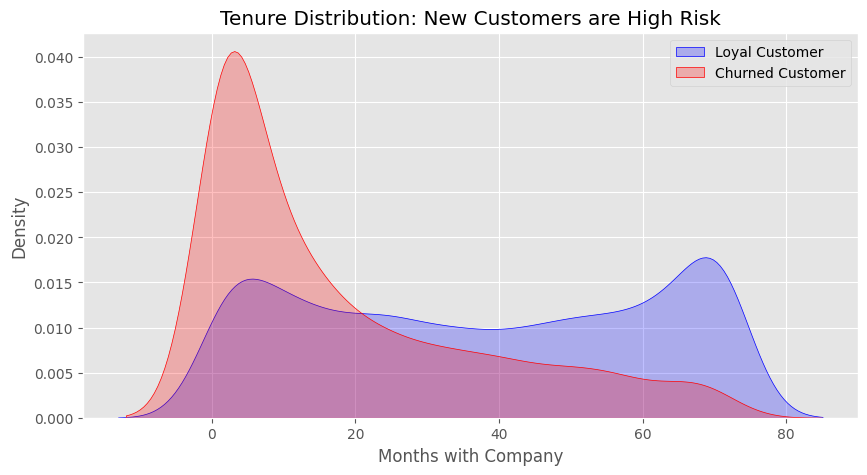

In [5]:
plt.figure(figsize=(10, 5))
# blue: retention; red: churn
sns.kdeplot(df[df['Churn'] == 'No']['tenure'], label='Loyal Customer', color='blue', shade=True)
sns.kdeplot(df[df['Churn'] == 'Yes']['tenure'], label='Churned Customer', color='red', shade=True)

plt.title('Tenure Distribution: New Customers are High Risk')
plt.xlabel('Months with Company')
plt.legend(loc='upper right') 
plt.show()

## Impact of Service Adoption on Churn

We create a new feature TotalServices by counting how many add-on services each customer subscribes to.
The results show a clear negative relationship: churn probability decreases as the number of subscribed services increases, suggesting stronger product engagement improves retention.

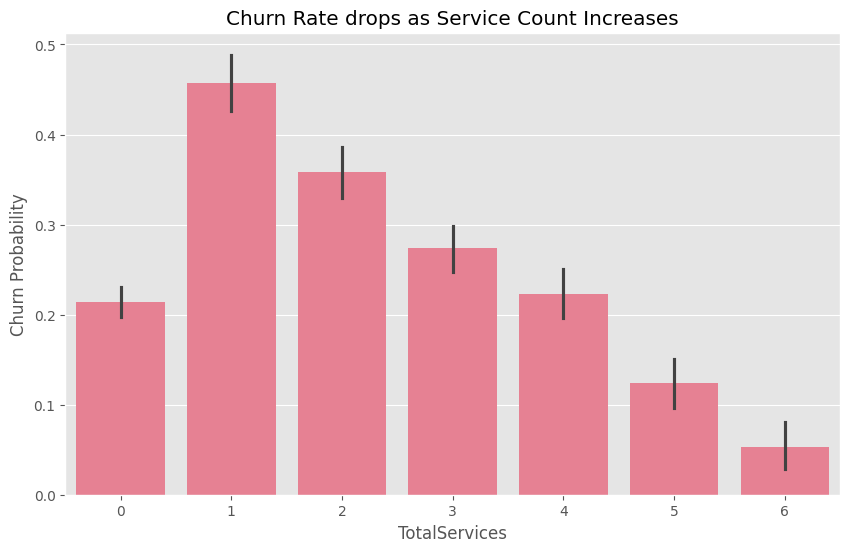

In [6]:
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['TotalServices'] = (df[addon_cols] == 'Yes').sum(axis=1)

plt.figure(figsize=(10, 6))
sns.barplot(x='TotalServices', y='Churn', data=df.replace({'Yes': 1, 'No': 0}))
plt.title('Churn Rate drops as Service Count Increases')
plt.ylabel('Churn Probability')
plt.show()

## Churn by Payment Method

We analyze churn behavior across different payment methods.
Customers using Electronic Check show a significantly higher churn rate compared to those using automatic payment methods such as bank transfer or credit card.

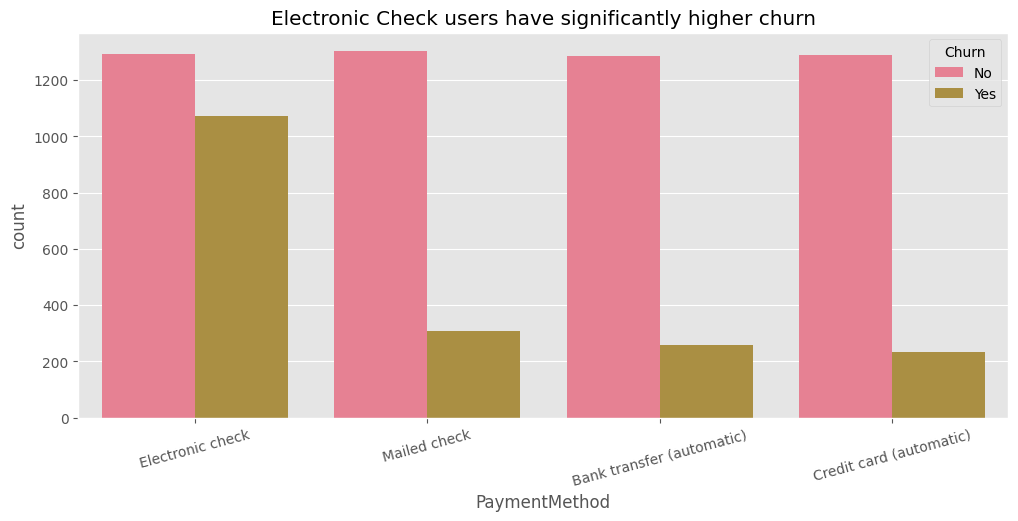

In [7]:
plt.figure(figsize=(12, 5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=15)
plt.title('Electronic Check users have significantly higher churn')
plt.show()

## Monthly Charges vs Contract Type and Churn

We examine how monthly charges interact with contract type and churn behavior.
Customers with higher monthly charges—especially under Month-to-Month contracts—are more likely to churn, indicating price sensitivity among short-term subscribers.

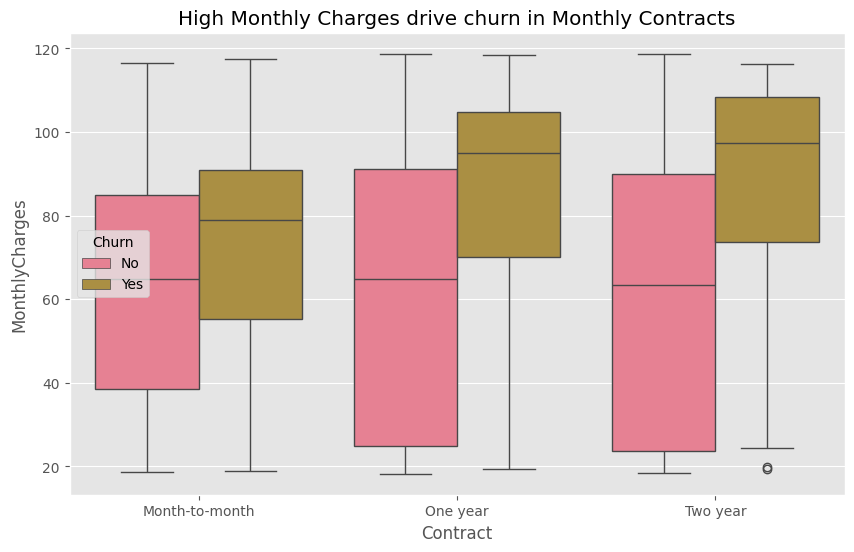

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Contract', y='MonthlyCharges', hue='Churn', data=df)
plt.title('High Monthly Charges drive churn in Monthly Contracts')
plt.show()

## Churn by Internet Service Type

We analyze churn behavior across different internet service types.
Customers using Fiber optic service exhibit a noticeably higher churn rate compared to DSL users, while customers without internet service show the lowest churn.

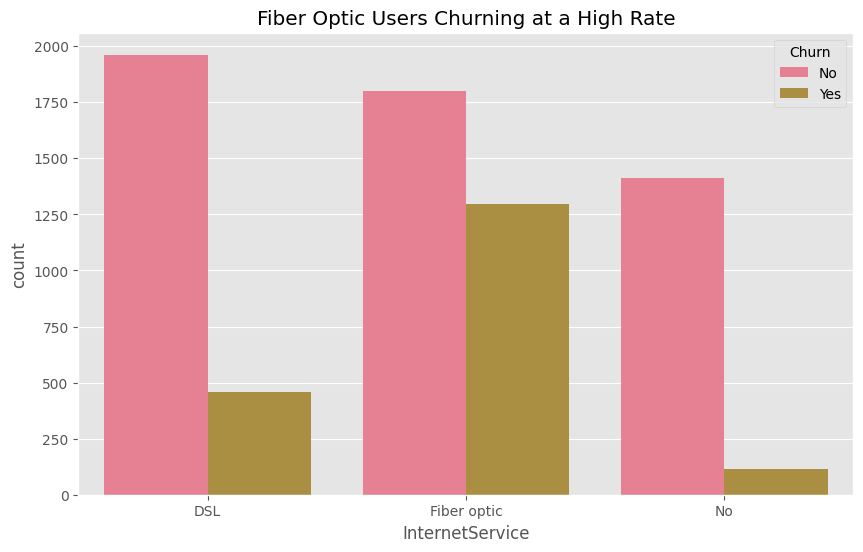

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Fiber Optic Users Churning at a High Rate')
plt.show()

## Paperless Billing and Churn

We examine whether customers enrolled in paperless billing have different churn behavior.
The results suggest that customers with paperless billing show a higher churn probability, indicating a potential association with more price-sensitive or digitally active users.

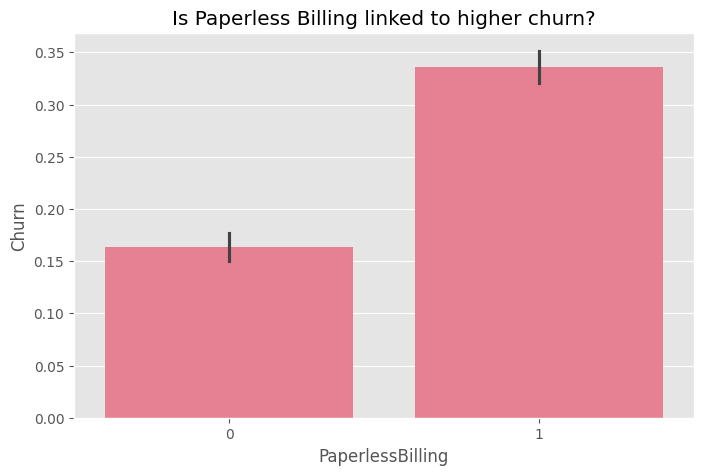

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(x='PaperlessBilling', y='Churn', data=df.replace({'Yes': 1, 'No': 0}))
plt.title('Is Paperless Billing linked to higher churn?')
plt.show()

## Correlation Analysis

We compute the correlation matrix for all numeric features, including a binary-encoded churn label.
The heatmap shows that tenure has the strongest negative correlation with churn, while monthly charges and total charges show moderate positive relationships, providing useful signals for modeling.

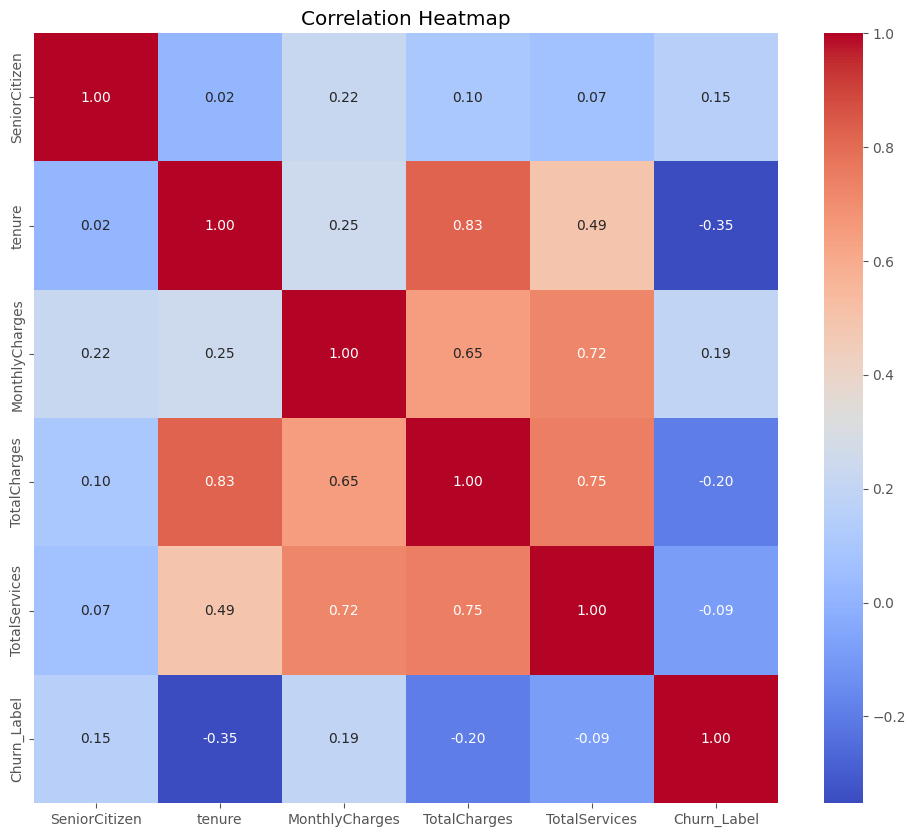

In [11]:
numeric_df = df.select_dtypes(include=[np.number])
numeric_df['Churn_Label'] = df['Churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Threshold Optimization using F1 Score

We train an XGBoost classifier and evaluate model performance across different probability thresholds.
By analyzing the precision-recall tradeoff, we identify an optimal threshold (~0.40) that maximizes the F1 score (0.6360), which is particularly important for handling class imbalance.

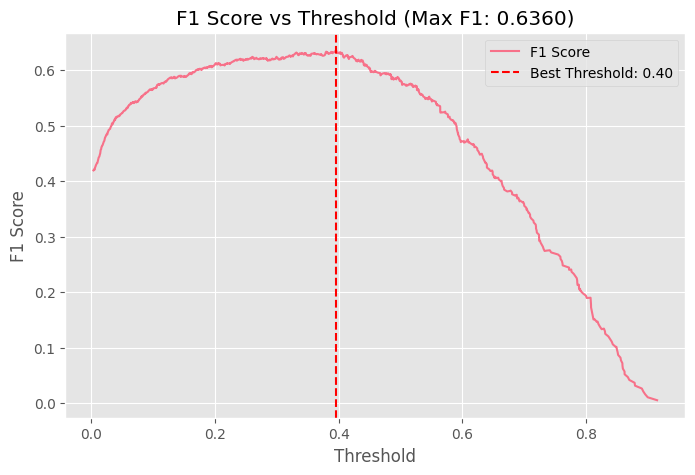

In [12]:
import sys
import os

sys.path.append(os.path.abspath('../src'))

from preprocess import load_and_preprocess

from sklearn.metrics import precision_recall_curve
from xgboost import XGBClassifier
from preprocess import load_and_preprocess

X_train, X_test, y_train, y_test = load_and_preprocess('../data/raw_data.csv')
model = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1)
model.fit(X_train, y_train)

y_scores = model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = np.max(f1_scores)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores[:-1], label='F1 Score')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold: {best_threshold:.2f}')
plt.title(f'F1 Score vs Threshold (Max F1: {best_f1:.4f})')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

## Best Model from MLflow (Class-Weight Adjusted XGBoost)

We load the train/test split and train the best XGBoost model selected from MLflow, where all candidate models use scale_pos_weight to address class imbalance.
By scanning thresholds on the test set, this model achieves a maximum F1 of ~0.639 with an optimal decision threshold around ~0.51, and the predicted probability distribution shows improved separation between churners and non-churners.

In [13]:
import sys
import os

sys.path.append(os.path.abspath('../src'))

from preprocess import load_and_preprocess

X_train, X_test, y_train, y_test = load_and_preprocess('../data/raw_data.csv')



In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

weight_val = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=50,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    scale_pos_weight=weight_val,
    random_state=42
)

model.fit(X_train, y_train)
y_scores = model.predict_proba(X_test)[:, 1]

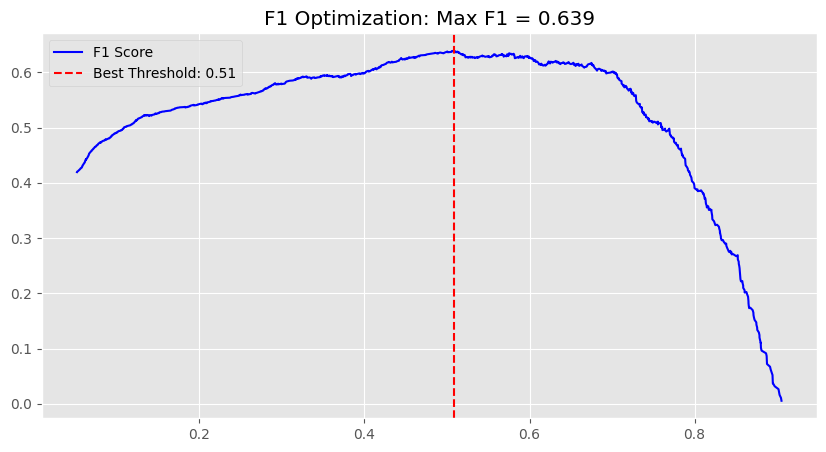

In [15]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_f1_idx = np.argmax(f1_scores)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores[:-1], 'b-', label='F1 Score')
plt.axvline(thresholds[best_f1_idx], color='r', linestyle='--', 
            label=f'Best Threshold: {thresholds[best_f1_idx]:.2f}')
plt.title(f'F1 Optimization: Max F1 = {np.max(f1_scores):.3f}')
plt.legend()
plt.show()

## Predicted Probability Distribution

We visualize the predicted probability distributions for churn and non-churn customers.
The weighted model produces clearer separation between the two classes, and the selected threshold (0.51) balances precision and recall effectively.

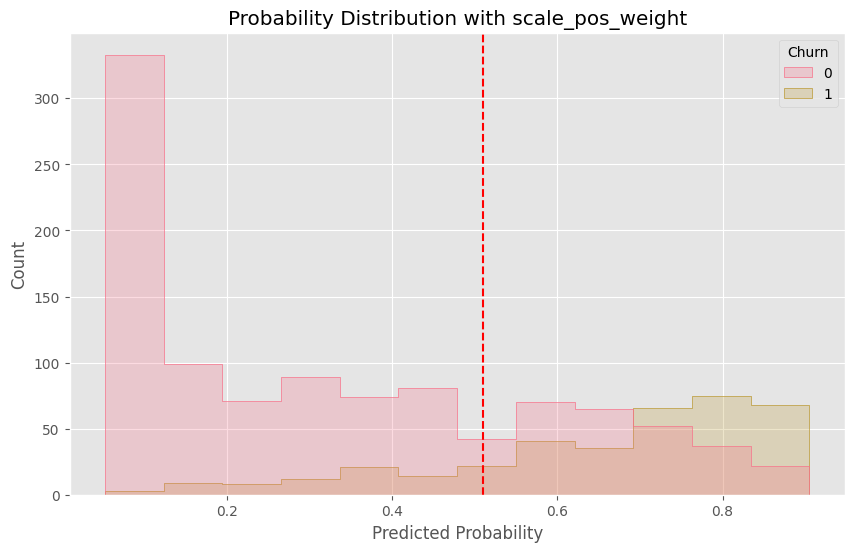

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(x=y_scores, hue=y_test, element="step", common_norm=False)
plt.axvline(0.51, color='red', linestyle='--', label=f'Best Threshold: 0.51')
plt.title("Probability Distribution with scale_pos_weight")
plt.xlabel("Predicted Probability")
plt.show()

## Final Model Evaluation – Confusion Matrix


In [17]:
analysis_df = pd.DataFrame({
    'Actual': y_test,
    'Prob': y_scores,
    'Prediction': (y_scores >= 0.40).astype(int)
})

false_negatives = analysis_df[(analysis_df['Actual'] == 1) & (analysis_df['Prediction'] == 0)]

print(f"False Negative: {len(false_negatives)}")


False Negative: 52


<Figure size 800x600 with 0 Axes>

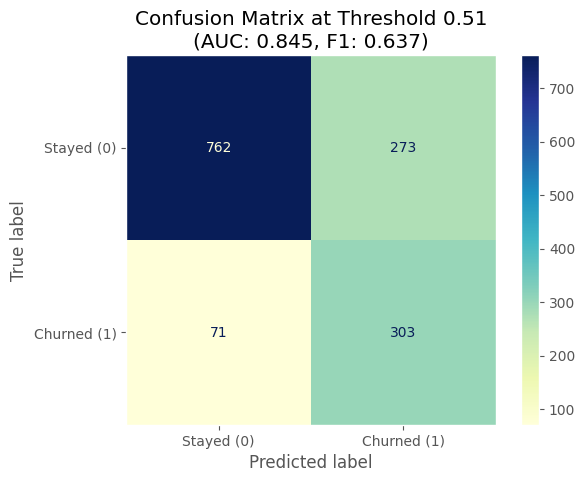

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_best = (y_scores >= 0.51).astype(int)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed (0)', 'Churned (1)'])
disp.plot(cmap='YlGnBu', values_format='d')
plt.title(f'Confusion Matrix at Threshold 0.51\n(AUC: 0.845, F1: 0.637)')
plt.grid(False) 
plt.show()

## Final Model Evaluation – Confusion Matrix & Business Metrics Continue

Using the optimized threshold (0.51), the confusion matrix is:

True Positives (TP) = 303

True Negatives (TN) = 762

False Positives (FP) = 273

False Negatives (FN) = 71

### Key Evaluation Metrics
Accuracy = (TP + TN) / Total ≈ 0.79

Accuracy measures overall prediction correctness.
However, in imbalanced datasets (26.5% churn), accuracy alone can be misleading — a naive model predicting “No churn” for everyone would still achieve ~73%.

Recall (Sensitivity) = TP / (TP + FN) ≈ 0.81

Recall measures how many actual churners we successfully identified.

The model captures ~81% of churners, meaning most high-risk customers are flagged.

In churn prediction, recall is critical because missing churners (FN = 71) directly leads to revenue loss.

From a business perspective:
Higher recall → fewer missed cancellations → better revenue protection.

Precision = TP / (TP + FP) ≈ 0.53

Precision measures how many predicted churners are truly churners.

About 53% of flagged customers actually churn.

The remaining 47% are false positives.

From a business perspective:
False positives increase intervention cost (discounts, outreach), but they are often less damaging than false negatives.

F1 Score = 0.637

F1 balances precision and recall.

Since churn prediction involves cost tradeoffs, F1 is more informative than accuracy.

The optimized threshold improves F1 by balancing missed churners and unnecessary retention cost.

AUC = 0.845

AUC measures ranking ability independent of threshold.

0.845 indicates strong separability between churners and non-churners.

This means the model is good at prioritizing high-risk customers even before threshold tuning.

### Business Interpretation

False Positives (273):
Customers flagged as high risk but who stayed.
While they increase campaign cost, proactive engagement may improve long-term loyalty.

False Negatives (71):
Churners who were not flagged.
These represent missed revenue protection opportunities.

Because churn is costly, we intentionally accept moderate precision to achieve high recall.
The threshold (0.51) reflects a strategic tradeoff between:

Retention campaign cost

Customer lifetime value (LTV)

Revenue loss from churn

### Strategic Takeaway

This model is not just statistically strong — it is business-aligned:

High recall protects revenue.

Controlled precision manages intervention cost.

Strong AUC ensures robust ranking ability.

Threshold tuning enables cost-sensitive decision making.